In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matrix_solvers import gauss_seidel, gaussian_elimination, jacobi_iteration

In [2]:
def create_grid(R,I):
    
    '''
    Create cell edges and centers for a domain of
    size R and for I cells
    
    Args:
        R: size of domain
        I: number of cells
        
    Returns:
        Delta_r: width of each cell
        centers: cell centers of the grid
        edges: cell edges of the grid
    '''
    
    Delta_r = float(R)/I # divide size by # of cells
    # calculate the centers by getting each Delta_r
    # and adding 0.5 Delta_R
    centers = np.arange(I)*Delta_r + 0.5*Delta_r
    # Get edges by going beyond one cell
    edges = np.arange(I+1)*Delta_r
    
    return Delta_r, centers, edges
    
def diffusion_solver(R, I,
                     D, Sig_a, nuSig_f, Q,
                     BC, geometry):
    
    '''
    Solve the diffusion equation in a 1-D geometry
    use cell-averaged quantities
    
    Args:
        R: size of domain
        I: number of cells
        D: function, D(r), returns diffusion coefficent at r
        Sig_a: function, Sig_a(r), returns macroscopic abs xs at r
        nuSig_f: function, nuSig_f(r), return nu*macroscopic fission xs at r
        Q: function, Q(r),  returns source at r
        BC: boundary conditions at r=R in form [A,B,C]
        geometry:
            0 = slab
            1 = cylindrical
            2 = spherical
    
    Returns:
        centers: cell centers of grid
        phi: cell-averaged value of scalar flux
    '''
    
    Delta_R, centers, edges = create_grid(R,I)
    # Matrices for Ax=b solve, or A\phi=b
    A = np.zeros((I+1, I+1)) 
    b = np.zeros(I+1)
    
    # define vectors of the surface areas S at cell edges
    # and  volumes V at dr
    if geometry == 0:  # slab
        S = np.zeros_like(edges)+1 # 1-D slab surface area
        S[0] = 0. # at the center make it zero, forces reflective BCs
        # in slab it's dV = dr
        V = np.zeros_like(edges)+ + Delta_R
    
    elif geometry == 1: # cylinder
        # cylinder surface area is 4pi*r^2
        S = 2.*np.pi*edges
        # cylinder differential volume is 4pi*r^2
        # must substract inner cylinder from next outer cylinder
        V = np.pi * (edges[1:I+1]**2 - edges[0:I]**2)
    
    elif geometry == 2: # sphere
        # sphere surface area = 4 pi r^2
        S = 4*np.pi*edges**2
        # volume is 4/3 pi r^3, must subtract inner sphere from outer sphere
        V = 4/3 * np.pi * (edges[1:I+1]**3 - edges[0:I]**3)
    
    # Setup the BC at R
    A[I,I] = (BC[0]/2 + BC[1]/Delta_R)
    A[I,I-1] = (BC[0]/2 - BC[1]/Delta_R)
    b[I] = BC[2]

    r = centers[0]
    Dplus = 0
    # fill A matrix
    for i in range(I):
        r = centers[i]
        Dminus = Dplus
        Dplus = 2*(D(r)*D(r+Delta_R)) / (D(r)+D(r+Delta_R))
        A[i,i] = 1/(Delta_R * V[i])*Dplus*S[i+1] + Sig_a(r) - nuSig_f(r)
        
        if i > 0:
            A[i,i-1] = -1*Dminus/(Delta_R*V[i])*S[i]
            A[i,i] += 1./(Delta_R*V[i])*Dminus*S[i]
        
        A[i,i+1] = -Dplus/(Delta_R*V[i])*S[i+1]
        b[i] = Q(r)

    # solve the system: YOU MUST USE YOUR OWN SOLVER, use function below to verify
    # phi = np.linalg.solve(A, b)
    phi, aug_m = gaussian_elimination(A, b)
    # remove last element of phi because it's outside the domain
    phi = phi[0:I]
    
    return centers, phi

def LU_factor(A):

    # Find the factors of L and U and store all in A
    # L has implied 1s along its diagonal

    N = A.shape[0]
    
    for col in range(0,N):
        for row in range(col+1,N):
            mod_row = np.copy(A[row])
            factor = mod_row[col]/A[col, col]

            mod_row -= factor*A[col,:]
            
            # store the factor in the modified row
            mod_row[col] = factor
            # store only the part of the modified row that makes U
            mod_row = mod_row[col:N]

            A[row, col:N] = mod_row
            
    return 


def LU_solve(A, b):

    [Nrow, Ncol] = A.shape
    N = Nrow
    x = np.zeros(N)
    y = np.zeros(N) # dummy variable for L^-1 b

    # do a forward solve for y in Ly = b
    # Remember L is stored as a lower triangular matrix in A
    # The real L has 1s along diagonal
    for row in range(N):
        RHS = b[row]
        for col in range(row):
            RHS -= y[col]*A[row,col]
        y[row] = RHS

    # Do a backwards solve
    for row in range(N-1, -1, -1):
        RHS = y[row]
        for col in range(row+1, N):
            RHS -= x[col]*A[row,col]
        
        x[row] = RHS/A[row,row]

    return x

def inverse_power(A, B, epsilon=1e-6):
    
    '''
    Solve the generalized eigenvalue problem Ax = lB
    using the inverse power iteration algorithm
    
    Args:
        A: LHS matrix (cannot be singular)
        B: The RHS matrix
        epsilon: tolerance on eigenvalue
        x: associated eigenvector
    Output:
        l: smallest eigenvalue of the problem
        x: associated eigenvector of smallest eigenvalue
    '''
    
    Nrows, Ncols = A.shape
    # Generate guess
    x = np.random.random((Nrows))
    x = x / np.linalg.norm(x)  # make norm(x) = 1
    
    l_old = 0
    converged = 0
    # compute LU factorization of A
    LU_factor(A)
    iteration = 0
    b_0s = []
    while not(converged):
        
        iteration += 1
        
        b = LU_solve(A, np.dot(B,x))
        b_0s.append(b[0])
        l = np.linalg.norm(b)
        x = b/l
        
        converged = (np.fabs(l-l_old) < epsilon)
        # print(f"Iteration: {iteration}, magnitude of l: {1/l:.4f}, epsilon:{np.fabs(l-l_old):.3e}")
        l_old = l
    
    sign = b_0s[iteration-1]/b_0s[iteration-2]

    return sign/l, x

def diffusion_setup(R, I, D, Sig_a, nuSig_f, BC, geometry):
    
    '''
    Solve the diffusion equation in a 1-D geometry
    use cell-averaged quantities
    
    Args:
        R: size of domain
        I: number of cells
        D: function, D(r), returns diffusion coefficent at r
        Sig_a: function, Sig_a(r), returns macroscopic abs xs at r
        nuSig_f: function, nuSig_f(r), return nu*macroscopic fission xs at r
        Q: function, Q(r),  returns source at r
        BC: boundary conditions at r=R in form [A,B,C]
        geometry:
            0 = slab
            1 = cylindrical
            2 = spherical
    
    Returns:
        centers: cell centers of grid
        phi: cell-averaged value of scalar flux
    '''
    
    Delta_R, centers, edges = create_grid(R,I)
    # Matrices for A and B containing loss and source terms, respectively
    A = np.zeros((I+1, I+1)) 
    B = np.zeros((I+1, I+1)) 
    
    # define vectors of the surface areas S at cell edges
    # and  volumes V at dr
    if geometry == 0:  # slab
        S = np.zeros_like(edges)+1 # 1-D slab surface area
        S[0] = 0. # at the center make it zero, forces reflective BCs
        # in slab it's dV = dr
        V = np.zeros_like(edges)+ + Delta_R
    
    elif geometry == 1: # cylinder
        # cylinder surface area is 4pi*r^2
        S = 2.*np.pi*edges
        # cylinder differential volume is 4pi*r^2
        # must substract inner cylinder from next outer cylinder
        V = np.pi * (edges[1:I+1]**2 - edges[0:I]**2)
    
    elif geometry == 2: # sphere
        # sphere surface area = 4 pi r^2
        S = 4*np.pi*edges**2
        # volume is 4/3 pi r^3, must subtract inner sphere from outer sphere
        V = 4/3 * np.pi * (edges[1:I+1]**3 - edges[0:I]**3)
    
    # Setup the BC at R
    A[I,I] = (BC[0]/2 + BC[1]/Delta_R)
    A[I,I-1] = (BC[0]/2 - BC[1]/Delta_R)

    # fill A matrix
    Dplus = 0
    for i in range(I):
        r = centers[i]
        Dminus = Dplus
        Dplus = 2*(D(r)*D(r+Delta_R)) / (D(r)+D(r+Delta_R))
        A[i,i] = 1/(Delta_R * V[i])*Dplus*S[i+1] + Sig_a(r)
        B[i,i] = nuSig_f(r)
        
        if i > 0:
            A[i,i-1] = -1*Dminus/(Delta_R*V[i])*S[i]
            A[i,i] += 1./(Delta_R*V[i])*Dminus*S[i]
        
        A[i,i+1] = -Dplus/(Delta_R*V[i])*S[i+1]
     
    return centers, A, B
        

def DiffusionEigenvalue(R, I,
                        D, Sig_a, nuSig_f,
                        BC, geometry, epsilon=1e-8):
    
    
    centers, A, B = diffusion_setup(R, I, D, Sig_a, nuSig_f, BC, geometry)
    l, phi = inverse_power(A,B,epsilon)
    # transform back from standard eigenvalue problem to generalized
    k = 1/l 
    phi = phi[0:I]
    
    return k, phi, centers

### Question 3

keff = 1.2561982562365221


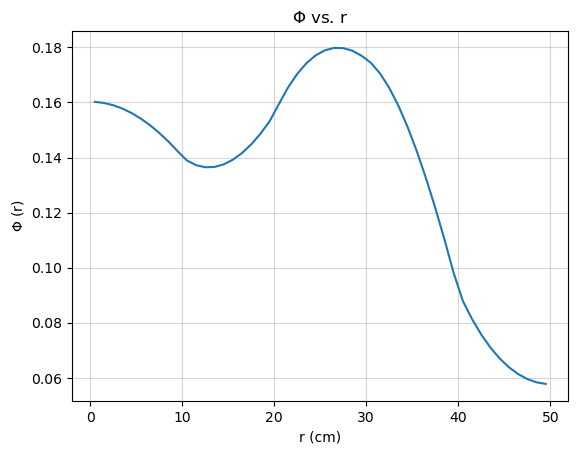

In [3]:
R = 50
I = 50
D = lambda r: 1.1*(r<=10) + 1.5*(10<r<=20) + 1.1*(20<r<=30) + 1.2*(30<r<=40) + 2.*(r>40)
Sig_a = lambda r: 0.070*(r<=10) + 0.085*(10<r<=20) + 0.070*(20<r<=30) + 0.065*(30<r<=40) + 0.020*(r>40)
nuSig_f = lambda r: 0.095*(r<=40) + 0*(r>40)
BC = [0, 1, 0]

# Cylinder reactor
keff, phi, centers = DiffusionEigenvalue(R, I, D, Sig_a, nuSig_f, BC, 1)
print(f"keff = {keff}")
# print(centers)

plt.plot(centers, phi)
plt.xlabel("r (cm)")
plt.ylabel("$\\Phi$ (r)")
plt.title("$\\Phi$ vs. r")
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()